# OptiScore — 포지션별 선수 시장 가치 예측 모델

5대 리그(분데스리가/라리가/프리미어리그/세리에A/리그1) 필드 플레이어의 시즌 스탯으로
Transfermarkt 시장 가치를 예측하는 XGBoost/LightGBM 모델을 포지션 그룹(8개)별로 학습한다.

이 노트북은 실제 학습 파이프라인인 [`ml/train.py`](../train.py)와
[`backend/features.py`](../../backend/features.py)를 그대로 불러와서 실행한다 —
로직을 노트북에 다시 손코딩하지 않는 이유는, 이전 버전에서 학습 코드와 서빙(예측
API) 코드에 피처 엔지니어링을 각각 손코딩했다가 `'태클'` vs `'태클 성공'` 같은
불일치 버그가 생겼기 때문이다. 이제 두 곳 모두 `features.py` 하나만 본다.

**1라운드 — 버그 수정** (자세한 내용은 [`../reports/model_evaluation.md`](../reports/model_evaluation.md) 6절):
1. 8개 포지션 모델을 전부 저장 (기존엔 마지막 포지션 모델만 저장되는 버그가 있었음)
2. StandardScaler 제거, `GroupShuffleSplit`으로 데이터 누수 수정, early stopping

**2라운드 — 성능 개선**:
3. 새 피처 3종: 리그 원-핫, 커리어 시즌차수, 2시즌 이동평균
4. `ml/tune.py`로 선수 단위 `GroupKFold` 기준 Optuna 하이퍼파라미터 재탐색
5. 포지션별로 XGBoost/LightGBM 중 더 나은 쪽 채택 (앙상블도 테스트했지만 기각)

**3라운드 — 평가 방법론 개선** (이 노트북에서 가장 중요한 부분, 아래 2절):
6. 측면 미드필더의 포지션 라벨이 다른 시즌과 일관되지 않은 선수를 정리
   (`backend/features.py`의 `_denoise_side_midfielder`)했지만 성능엔 변화가 없었고,
   그 과정에서 **표본이 작은 포지션은 단일 train/test 분할로 평가하면 R²가
   4%~56%까지 요동친다**는 걸 발견했다. 그래서 공식 성능 지표를 단일 분할에서
   선수 단위 `GroupKFold` 4-fold 평균으로 바꿨다.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(ROOT / "backend"))
sys.path.insert(0, str(ROOT / "ml"))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import features
import train as train_module

pd.set_option("display.max_columns", 20)
sns.set_style("whitegrid")

## 1. 데이터 로딩 · 클리닝 · 피처 엔지니어링

In [2]:
raw = train_module.load_raw()
df = train_module.load_data()
print(f"학습 대상: {len(df):,}건, 선수 {df['name_key'].nunique():,}명, 포지션 그룹 {df['포지션_그룹'].nunique()}개")
df[["name_key", "시즌", "포지션_그룹", "TM_시장가치_EUR", "log_현재_시장가치", "log_전시즌_시장가치"]].head()

학습 대상: 11,637건, 선수 3,929명, 포지션 그룹 8개


,name_key,시즌,포지션_그룹,TM_시장가치_EUR,log_현재_시장가치,log_전시즌_시장가치
7938,aaron connolly,2019-2020,스트라이커,3666667.0,15.114794,0.000000
7179,aaron cresswell,2016-2017,중앙 수비수,12000000.0,16.300417,0.000000
7358,aaron cresswell,2017-2018,중앙 수비수,12000000.0,16.300417,16.300417
7573,aaron cresswell,2018-2019,중앙 수비수,10000000.0,16.118096,16.300417
7896,aaron cresswell,2019-2020,중앙 수비수,7500000.0,15.830414,16.118096


## 2. 포지션별 학습 및 평가

`train_all()`은 포지션마다 세 가지를 계산한다:
- `naive_split`: 기존 코드와 동일한 완전 랜덤 분할 (비교용, 데이터 누수 있음)
- `cv_split`: **공식 성능 지표.** 선수 단위 `GroupKFold`(4-fold) 평균 R²/RMSE
- `grouped_split`: 실제로 저장할 모델 하나를 학습한 단일 선수 그룹 분할 (피처
  중요도·오차 분석 예시용 — 아래에서 보겠지만 이 숫자 하나만 보면 안 된다)

`load_position_configs()`가 [`../reports/best_params.json`](../reports/best_params.json)
(`ml/tune.py` 재탐색 결과)을 읽어서 포지션별로 XGBoost/LightGBM 중 교차검증 점수가
더 높은 쪽을 자동으로 선택한다.

In [3]:
bundle, results = train_module.train_all(df)

공격형 미드필더 [xgboost]: 랜덤분할 R²=72.83% -> CV R²=75.71%(±2.49%) (단일분할 예시=80.40%, n=1012, best_iter=375)


수비형 미드필더 [xgboost]: 랜덤분할 R²=76.82% -> CV R²=76.63%(±2.22%) (단일분할 예시=70.83%, n=1381, best_iter=655)


스트라이커 [xgboost]: 랜덤분할 R²=78.38% -> CV R²=78.20%(±1.94%) (단일분할 예시=70.19%, n=1767, best_iter=426)


윙어 [xgboost]: 랜덤분할 R²=74.68% -> CV R²=70.43%(±2.97%) (단일분할 예시=73.03%, n=1362, best_iter=267)


중앙 미드필더 [xgboost]: 랜덤분할 R²=79.49% -> CV R²=76.90%(±3.15%) (단일분할 예시=73.57%, n=1455, best_iter=359)


중앙 수비수 [xgboost]: 랜덤분할 R²=78.41% -> CV R²=79.16%(±1.17%) (단일분할 예시=79.89%, n=2511, best_iter=275)


측면 미드필더 [lightgbm]: 랜덤분할 R²=59.62% -> CV R²=44.28%(±17.29%) (단일분할 예시=4.25%, n=343, best_iter=539)


측면 수비수 [lightgbm]: 랜덤분할 R²=65.31% -> CV R²=73.21%(±4.10%) (단일분할 예시=76.75%, n=1806, best_iter=551)


In [4]:
summary = pd.DataFrame([
    {
        "포지션": pos,
        "모델": d["model_type"],
        "표본수": d["n_rows"],
        "선수수": d["n_players"],
        "CV R² (공식)": d["cv_split"]["r2_mean"],
        "CV 표준편차": d["cv_split"]["r2_std"],
        "단일분할 예시 R²": d["grouped_split"]["r2"],
        "R² (기존 랜덤분할)": d["naive_split"]["r2"],
    }
    for pos, d in results.items()
]).sort_values("CV R² (공식)", ascending=False)
summary.style.format({
    "CV R² (공식)": "{:.1%}", "CV 표준편차": "{:.1%}",
    "단일분할 예시 R²": "{:.1%}", "R² (기존 랜덤분할)": "{:.1%}",
})

,포지션,모델,표본수,선수수,CV R² (공식),CV 표준편차,단일분할 예시 R²,R² (기존 랜덤분할)
5,중앙 수비수,xgboost,2511,868,79.2%,1.2%,79.9%,78.4%
2,스트라이커,xgboost,1767,607,78.2%,1.9%,70.2%,78.4%
4,중앙 미드필더,xgboost,1455,501,76.9%,3.2%,73.6%,79.5%
1,수비형 미드필더,xgboost,1381,422,76.6%,2.2%,70.8%,76.8%
0,공격형 미드필더,xgboost,1012,336,75.7%,2.5%,80.4%,72.8%
7,측면 수비수,lightgbm,1806,627,73.2%,4.1%,76.8%,65.3%
3,윙어,xgboost,1362,462,70.4%,3.0%,73.0%,74.7%
6,측면 미드필더,lightgbm,343,154,44.3%,17.3%,4.3%,59.6%


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_40308\2897057171.py:11: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_40308\2897057171.py:11: UserWarning: Glyph 50521 (\N{HANGUL SYLLABLE ANG}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_40308\2897057171.py:11: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_40308\2897057171.py:11: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_40308\2897057171.py:11: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_40308\2897057171.py:11: UserWarning: Glyph 53

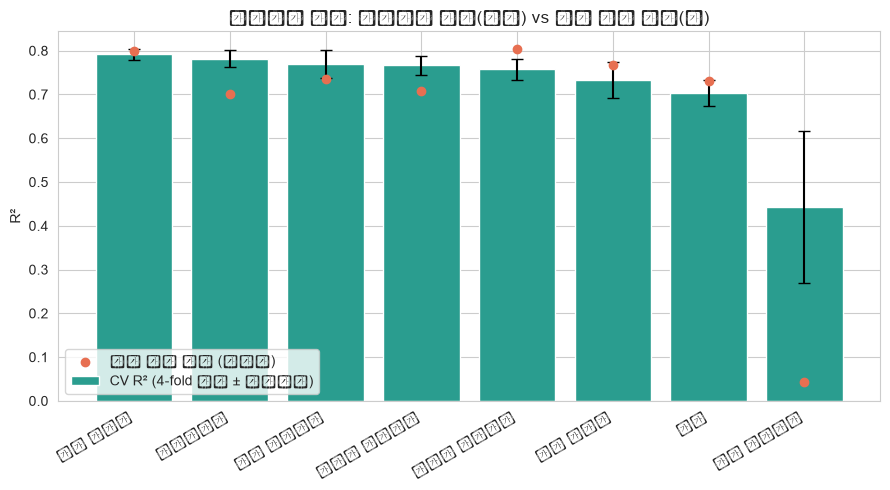

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(summary))
ax.bar(x, summary["CV R² (공식)"], yerr=summary["CV 표준편차"], capsize=4,
       color="#2a9d8f", label="CV R² (4-fold 평균 ± 표준편차)")
ax.scatter(x, summary["단일분할 예시 R²"], color="#e76f51", zorder=5, label="단일 분할 예시 (참고용)")
ax.set_xticks(list(x))
ax.set_xticklabels(summary["포지션"], rotation=30, ha="right")
ax.set_ylabel("R²")
ax.set_title("포지션별 성능: 교차검증 평균(막대) vs 단일 분할 예시(점)")
ax.legend()
fig.tight_layout()
plt.show()

막대(교차검증 평균)와 점(단일 분할 예시)이 대체로 가깝지만, **측면 미드필더**는
확연히 벌어져 있다 — 표준편차 막대(오차 막대)도 다른 포지션보다 훨씬 크다. 표본이
343건(154명)으로 다른 포지션의 1/4~1/7 수준이라, 어떤 선수가 test로 뽑히느냐에
따라 단일 분할 R²가 크게 흔들린다(실제로 확인한 범위: 4%~56%). 이게 바로 공식
지표를 교차검증 평균으로 정한 이유다. 자세한 조사 과정은
[`model_evaluation.md`](../reports/model_evaluation.md) -1절과 5절 참고.

## 3. 피처 중요도 — 스트라이커 예시

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_40308\3636688600.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x="importance", y="feature", ax=ax, palette="viridis")
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_40308\3636688600.py:9: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_40308\3636688600.py:9: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_40308\3636688600.py:9: UserWarning: Glyph 51596 (\N{HANGUL SYLLABLE JEUN}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_40308\3636688600.py:9: UserWarning: Glyph 51109 (\N{HANGUL SYL

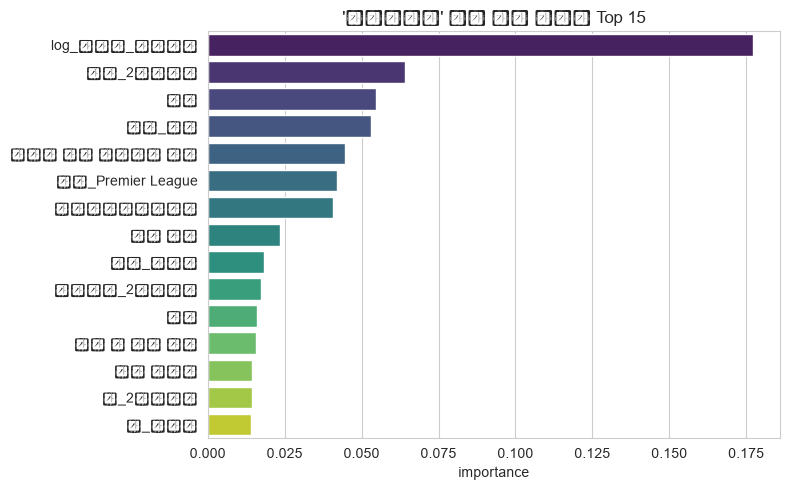

In [6]:
example_position = "스트라이커"
imp_df = pd.DataFrame(results[example_position]["top_features"])

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=imp_df, x="importance", y="feature", ax=ax, palette="viridis")
ax.set_title(f"'{example_position}' 모델 피처 중요도 Top 15")
ax.set_xlabel("importance")
ax.set_ylabel("")
fig.tight_layout()
plt.show()

`log_전시즌_시장가치`(작년 시장 가치)가 전 포지션에서 1위다. 시장가치는 원래
전년도 값과 강한 자기상관이 있어 자연스러운 결과이지만, 이 모델이 "성과로부터 가치를
추정"한다기보다 "작년 가격 + 보정"에 가깝다는 한계이기도 하다.

이번 라운드에서 추가한 `리그_Premier League`도 대부분 포지션에서 상위 6위 안에
들었다 — 같은 스탯이라도 프리미어리그 선수가 더 비싸게 평가된다는 가설이 실제로
예측에 기여하는 신호였다는 뜻이다.

## 4. 오차 분석 — 과소평가된 슈퍼스타

In [7]:
under = pd.DataFrame(results[example_position]["underrated_top5"])
over = pd.DataFrame(results[example_position]["overrated_top5"])

print(f"[{example_position}] 과소평가 TOP 5 (모델이 실제보다 훨씬 낮게 예측)")
display(under)
print(f"\n[{example_position}] 과대평가 TOP 5 (모델이 실제보다 훨씬 높게 예측)")
display(over)

[스트라이커] 과소평가 TOP 5 (모델이 실제보다 훨씬 낮게 예측)


,선수명,실제_가치,예측_가치,오차
0,gonzalo higuain,75000000.0,17594648.0,-57405352.0
1,luis suárez,90000000.0,41562836.0,-48437164.0
2,harry kane,116666667.0,77450512.0,-39216155.0
3,harry kane,150000000.0,111719496.0,-38280504.0
4,harry kane,135000000.0,101901384.0,-33098616.0



[스트라이커] 과대평가 TOP 5 (모델이 실제보다 훨씬 높게 예측)


,선수명,실제_가치,예측_가치,오차
0,paulinho,4750000.0,38733212.0,33983212.0
1,harry kane,82500000.0,110881384.0,28381384.0
2,joao pedro,10500000.0,37781152.0,27281152.0
3,alexis sánchez,11166667.0,37501156.0,26334489.0
4,joao pedro,400000.0,22925176.0,22525176.0


Gonzalo Higuaín, Luis Suárez, Harry Kane, Son Heung-min, Eden Hazard, Bukayo Saka처럼
브랜드 가치·이적시장 하이프가 큰 선수는 일관되게 과소평가된다 — 시즌 스탯만으로는
설명되지 않는 "시장 프리미엄"이 있다는 뜻이다. 피처를 추가하고 하이퍼파라미터를
재탐색해도 이 패턴 자체는 사라지지 않았다 (2라운드 이후에도 동일). 자세한 목록은
[`model_evaluation.md`](../reports/model_evaluation.md) 4절 참고.

## 5. 잔차 분석

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_40308\4023203639.py:17: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_40308\4023203639.py:17: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_40308\4023203639.py:17: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_40308\4023203639.py:17: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_40308\4023203639.py:17: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_40308\4023203639.py:17: UserWarning: Glyph 52

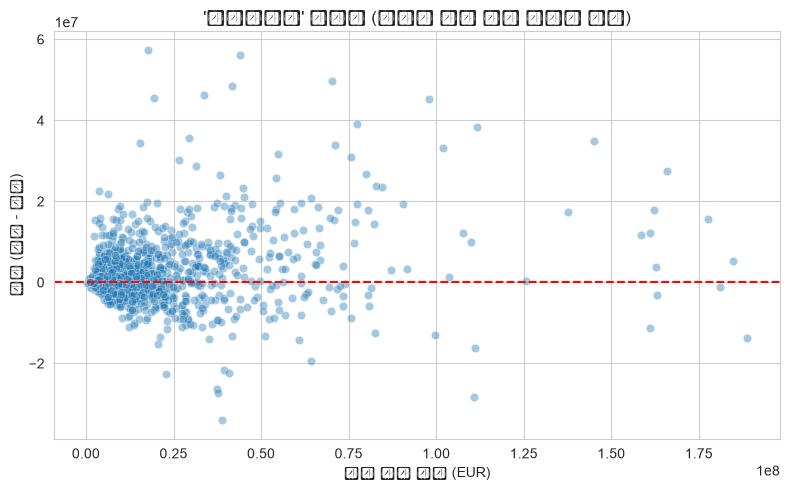

In [8]:
group_df = df[df["포지션_그룹"] == example_position].copy()
X, y = train_module._make_xy(group_df)
model = bundle[example_position]["model"]

import numpy as np
log_pred = model.predict(X[bundle[example_position]["feature_cols"]])
y_pred = np.expm1(log_pred)
y_true = np.expm1(y)
residuals = y_true - y_pred

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.4, ax=ax)
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("예측 시장 가치 (EUR)")
ax.set_ylabel("잔차 (실제 - 예측)")
ax.set_title(f"'{example_position}' 잔차도 (학습에 쓰인 전체 데이터 기준)")
fig.tight_layout()
plt.show()

## 6. 모델 저장

포지션별 모델을 전부 `backend/models/model_bundle.pkl`에 저장한다 (기존 버그였던
"마지막 포지션 모델만 저장" 문제 수정). `backend/app.py`는 이 번들을 로드해서
선수 포지션에 맞는 모델로 예측한다.

In [9]:
import joblib

BUNDLE_PATH = ROOT / "backend" / "models" / "model_bundle.pkl"
joblib.dump(bundle, BUNDLE_PATH)
print(f"저장 완료: {BUNDLE_PATH} ({len(bundle)}개 포지션)")

pred_df = train_module.predict_all(df, bundle)
out = train_module.build_prediction_excel(raw, pred_df)
out.to_excel(ROOT / "data" / "player_with_pred.xlsx", index=False)
print("예측 결과 저장 완료: data/player_with_pred.xlsx")

저장 완료: C:\Users\SONGSH\Desktop\capstone_design\backend\models\model_bundle.pkl (8개 포지션)


예측 결과 저장 완료: data/player_with_pred.xlsx


## 7. 한계 및 향후 개선 과제

1. **측면 미드필더는 근본적으로 데이터가 부족하다** (343건/154명, 다른 포지션의
   1/4~1/7). 포지션 라벨을 정리해봤지만(다른 시즌과 일관되지 않는 9명, 13개
   시즌 재분류) 교차검증 R²는 45.8%→44.3%로 사실상 그대로였다 — 라벨 노이즈가
   아니라 순수한 표본 부족이 원인이었다. 더 많은 시즌/리그 데이터 없이는 해결이
   어렵다.
2. **슈퍼스타 과소평가**: 시즌 스탯만으로는 브랜드/하이프 요인을 설명하지 못한다.
   피처·하이퍼파라미터를 개선해도 해결되지 않는 구조적 한계로 확인됐다.
3. **신인 선수**: "작년 시장 가치"가 없는 데뷔 시즌 선수에 대한 예측 정확도는 별도
   검증이 필요하다. `/api/predict`의 커리어 시즌차수·2시즌평균도 실시간 입력에서는
   근사치임을 감안해야 한다.
4. **더 엄격한 검증**: 지금의 선수 그룹 분할도 여전히 "무작위 선수"를 떼어내는 것이라,
   실제 배포 시나리오(과거 시즌으로 학습해 미래 시즌을 예측)보다는 관대한 평가다.
   시즌 기준 시간 분할(예: 2023-24 이전 시즌 학습 → 2024-25 시즌 테스트)이 다음 단계로
   더 적합하다.
5. **앙상블은 테스트했지만 채택하지 않음**: XGBoost+LightGBM 평균 앙상블이 5/8
   포지션에서 근소하게 더 좋았지만(최대 +0.9%p) 나머지 3개에서는 더 나빴다. 이득 대비
   서빙 복잡도(모델 2개 항상 유지)가 커서 포지션별 단일 최고 모델만 채택했다.
6. **평가 방법론**: 표본이 작은 포지션의 단일 분할 R²는 신뢰할 수 없다는 걸 이번에
   확인했다 (2절). 지금은 4-fold CV로 완화했지만, 표본이 더 작은 하위 그룹을 다룰
   일이 있다면 fold 수를 늘리거나 반복 교차검증(repeated CV)을 고려해야 한다.